# Tugas 1B - TF-IDF Sentence Level (Manchester)

**Author:** Muhammad Razan Parisya Putra  
**Notebook:** `Tugas 1B - TF-IDF Sentence Manchester`

---

## Objective

Menerapkan TF-IDF pada level kalimat (sentence-level) menggunakan teks tentang Manchester.
Setiap kalimat diperlakukan sebagai satu dokumen, sehingga TF-IDF dapat mengidentifikasi
kata kunci yang paling merepresentasikan setiap kalimat.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Corpus: Kalimat tentang Manchester

Corpus terdiri dari beberapa kalimat tentang Manchester (kota, sepak bola, budaya, sejarah).
Setiap kalimat = satu dokumen.

In [2]:
sentences = [
    "Manchester is a major city in the northwest of England with a rich industrial heritage.",
    "Manchester United and Manchester City are two of the most famous football clubs in the world.",
    "The city of Manchester played a key role in the Industrial Revolution during the 18th century.",
    "Old Trafford is the home stadium of Manchester United and can hold over 74000 spectators.",
    "Manchester has a vibrant music scene and was the birthplace of bands like Oasis and The Smiths.",
    "The University of Manchester is one of the top research universities in the United Kingdom.",
    "Manchester City won the Premier League title and became champions of Europe in 2023.",
    "The Manchester Ship Canal transformed the city into an inland port in the late 1800s.",
    "Manchester is known for its rainy weather but also for its warm and friendly people.",
    "The Etihad Stadium is the home ground of Manchester City Football Club.",
]

print(f'Jumlah kalimat (dokumen): {len(sentences)}')
print()
for i, s in enumerate(sentences):
    print(f'  S{i}: {s}')

Jumlah kalimat (dokumen): 10

  S0: Manchester is a major city in the northwest of England with a rich industrial heritage.
  S1: Manchester United and Manchester City are two of the most famous football clubs in the world.
  S2: The city of Manchester played a key role in the Industrial Revolution during the 18th century.
  S3: Old Trafford is the home stadium of Manchester United and can hold over 74000 spectators.
  S4: Manchester has a vibrant music scene and was the birthplace of bands like Oasis and The Smiths.
  S5: The University of Manchester is one of the top research universities in the United Kingdom.
  S6: Manchester City won the Premier League title and became champions of Europe in 2023.
  S7: The Manchester Ship Canal transformed the city into an inland port in the late 1800s.
  S8: Manchester is known for its rainy weather but also for its warm and friendly people.
  S9: The Etihad Stadium is the home ground of Manchester City Football Club.


## 3. Preprocessing

In [3]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

sentences_clean = [preprocess(s) for s in sentences]

print('Contoh preprocessing:')
print(f'  BEFORE: {sentences[1]}')
print(f'  AFTER : {sentences_clean[1]}')

Contoh preprocessing:
  BEFORE: Manchester United and Manchester City are two of the most famous football clubs in the world.
  AFTER : manchester united and manchester city are two of the most famous football clubs in the world


## 4. Bag of Words (CountVectorizer)

In [4]:
bow_vec = CountVectorizer()
bow_matrix = bow_vec.fit_transform(sentences_clean)

vocab = bow_vec.get_feature_names_out()

print(f'BoW Matrix : {bow_matrix.shape}  (kalimat x kata unik)')
print(f'Vocabulary : {len(vocab)} kata unik')

# Tampilkan matriks BoW lengkap (karena corpus kecil)
df_bow = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vocab,
    index=[f'S{i}' for i in range(len(sentences))]
)
print('\nBoW Matrix (lengkap):')
df_bow

BoW Matrix : (10, 81)  (kalimat x kata unik)
Vocabulary : 81 kata unik

BoW Matrix (lengkap):


,also,an,and,are,bands,became,birthplace,but,can,canal,...,united,universities,university,vibrant,warm,was,weather,with,won,world
S0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
S1,0,0,1,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
S2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S3,0,0,1,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
S4,0,0,2,0,1,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,0
S5,0,0,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0
S6,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
S7,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
S8,1,0,1,0,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
S9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 5. TF-IDF (TfidfTransformer)

In [5]:
tfidf_transformer = TfidfTransformer()
tfidf_matrix = tfidf_transformer.fit_transform(bow_matrix)

print(f'TF-IDF Matrix: {tfidf_matrix.shape}')

# Tampilkan matriks TF-IDF lengkap
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray().round(4),
    columns=vocab,
    index=[f'S{i}' for i in range(len(sentences))]
)
print('\nTF-IDF Matrix (lengkap):')
df_tfidf

TF-IDF Matrix: (10, 81)

TF-IDF Matrix (lengkap):


,also,an,and,are,bands,became,birthplace,but,can,canal,...,united,universities,university,vibrant,warm,was,weather,with,won,world
S0,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.3503,0.0000,0.0000
S1,0.0000,0.0000,0.1916,0.3227,0.000,0.0000,0.000,0.0000,0.0000,0.0000,...,0.2400,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.0000,0.3227
S2,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000
S3,0.0000,0.0000,0.1958,0.0000,0.000,0.0000,0.000,0.0000,0.3297,0.0000,...,0.2452,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000
S4,0.0000,0.0000,0.3373,0.0000,0.284,0.0000,0.284,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.284,0.0000,0.284,0.0000,0.0000,0.0000,0.0000
S5,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.0000,...,0.2401,0.3228,0.3228,0.000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000
S6,0.0000,0.0000,0.2046,0.0000,0.000,0.3445,0.000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.3445,0.0000
S7,0.0000,0.3133,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.3133,...,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000
S8,0.2437,0.0000,0.1447,0.0000,0.000,0.0000,0.000,0.2437,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.000,0.2437,0.000,0.2437,0.0000,0.0000,0.0000
S9,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000


## 6. Kata Kunci per Kalimat

TF-IDF mengidentifikasi kata yang paling merepresentasikan setiap kalimat.
Kata "manchester" muncul di semua kalimat sehingga bobotnya rendah.
Kata spesifik seperti "oasis", "stadium", "revolution" mendapat bobot tinggi.

In [6]:
print('Kata kunci per kalimat (top 3 TF-IDF):')
print('=' * 90)

for i in range(len(sentences)):
    row = tfidf_matrix[i].toarray().flatten()
    top3 = row.argsort()[::-1][:3]
    keywords = [f'{vocab[idx]} ({row[idx]:.3f})' for idx in top3]
    print(f'  S{i}: {sentences[i][:70]}...')
    print(f'      Keywords: {" | ".join(keywords)}')
    print()

Kata kunci per kalimat (top 3 TF-IDF):
  S0: Manchester is a major city in the northwest of England with a rich ind...
      Keywords: with (0.350) | heritage (0.350) | major (0.350)

  S1: Manchester United and Manchester City are two of the most famous footb...
      Keywords: world (0.323) | two (0.323) | clubs (0.323)

  S2: The city of Manchester played a key role in the Industrial Revolution ...
      Keywords: the (0.382) | th (0.315) | played (0.315)

  S3: Old Trafford is the home stadium of Manchester United and can hold ove...
      Keywords: trafford (0.330) | hold (0.330) | old (0.330)

  S4: Manchester has a vibrant music scene and was the birthplace of bands l...
      Keywords: and (0.337) | vibrant (0.284) | has (0.284)

  S5: The University of Manchester is one of the top research universities i...
      Keywords: the (0.392) | top (0.323) | university (0.323)

  S6: Manchester City won the Premier League title and became champions of E...
      Keywords: won (0.344) 

## 7. Visualisasi Heatmap TF-IDF

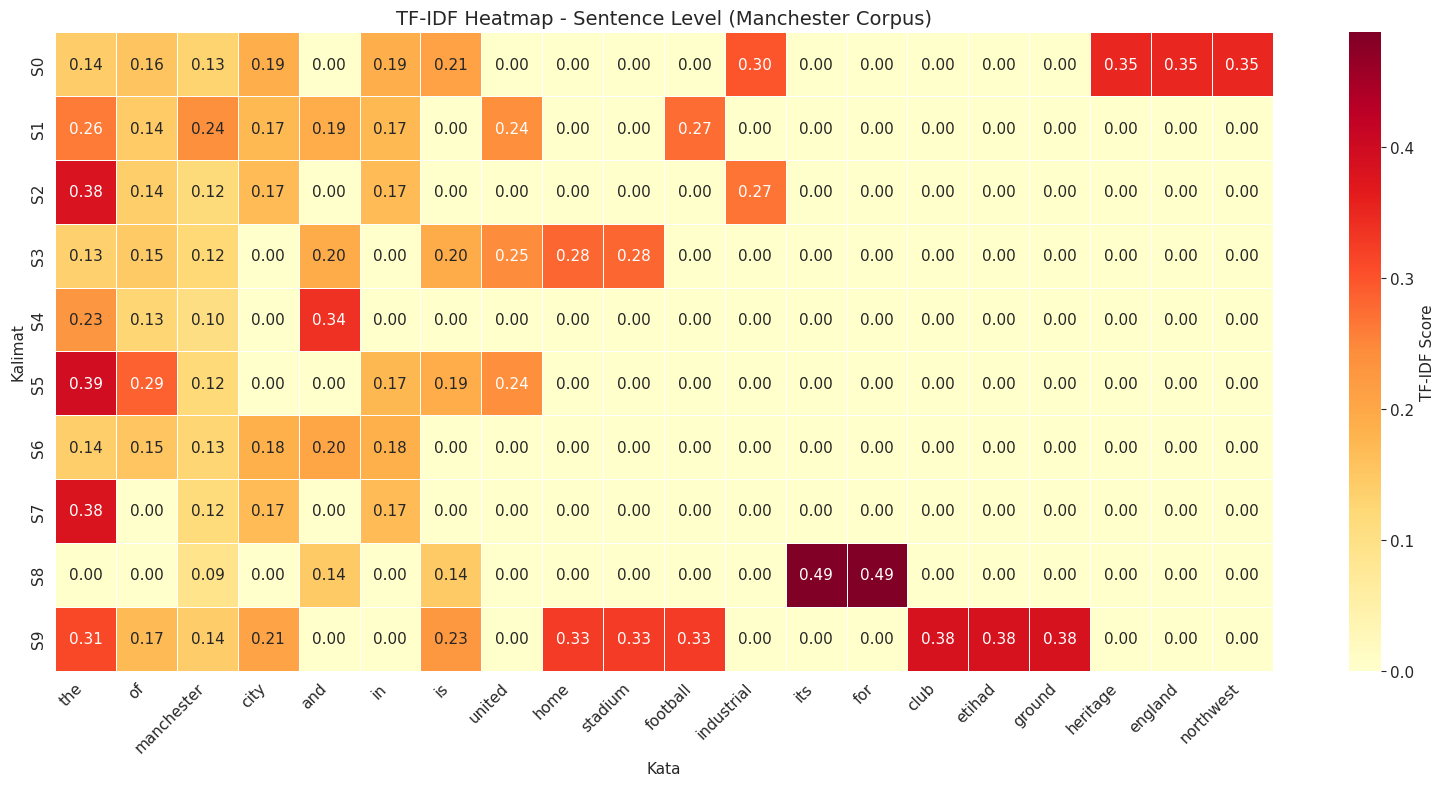

In [7]:
# Ambil top 20 kata berdasarkan rata-rata TF-IDF tertinggi
mean_scores = tfidf_matrix.toarray().mean(axis=0)
top20_idx = mean_scores.argsort()[::-1][:20]
top20_words = vocab[top20_idx]

# Heatmap
fig, ax = plt.subplots(figsize=(16, 8))
heatmap_data = df_tfidf[top20_words]

sns.heatmap(
    heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'TF-IDF Score'}
)
ax.set_title('TF-IDF Heatmap - Sentence Level (Manchester Corpus)', fontsize=14)
ax.set_ylabel('Kalimat')
ax.set_xlabel('Kata')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Perbandingan BoW vs TF-IDF untuk kata "manchester"

Kata "manchester" muncul di semua 10 kalimat. Mari lihat bagaimana BoW dan TF-IDF
memperlakukan kata ini secara berbeda.

In [8]:
# Cari index kata 'manchester'
manc_idx = list(vocab).index('manchester')

bow_manc = bow_matrix[:, manc_idx].toarray().flatten()
tfidf_manc = tfidf_matrix[:, manc_idx].toarray().flatten()

comparison = pd.DataFrame({
    'Kalimat': [f'S{i}' for i in range(len(sentences))],
    'BoW (manchester)': bow_manc.astype(int),
    'TF-IDF (manchester)': tfidf_manc.round(4),
})

print('Perbandingan BoW vs TF-IDF untuk kata "manchester":')
print(comparison.to_string(index=False))
print()
print('Catatan:')
print('  Meskipun "manchester" muncul di SEMUA kalimat (BoW selalu >= 1),')
print('  TF-IDF memberikan bobot yang rendah karena kata ini tidak membantu')
print('  membedakan satu kalimat dari kalimat lainnya (IDF rendah).')

Perbandingan BoW vs TF-IDF untuk kata "manchester":
Kalimat  BoW (manchester)  TF-IDF (manchester)
     S0                 1               0.1295
     S1                 2               0.2386
     S2                 1               0.1163
     S3                 1               0.1219
     S4                 1               0.1050
     S5                 1               0.1194
     S6                 1               0.1274
     S7                 1               0.1158
     S8                 1               0.0901
     S9                 1               0.1418

Catatan:
  Meskipun "manchester" muncul di SEMUA kalimat (BoW selalu >= 1),
  TF-IDF memberikan bobot yang rendah karena kata ini tidak membantu
  membedakan satu kalimat dari kalimat lainnya (IDF rendah).


## 9. Kesimpulan

Dari analisis sentence-level TF-IDF pada corpus Manchester:

- Kata "manchester" muncul di semua kalimat, sehingga TF-IDF memberikan bobot rendah meskipun frekuensinya tinggi di BoW.
- Setiap kalimat memiliki kata kunci unik yang diidentifikasi oleh TF-IDF: S0 tentang "heritage"/"industrial", S1 tentang "clubs"/"football", S4 tentang "music"/"oasis", dst.
- Heatmap menunjukkan distribusi bobot secara visual, kata yang terang (skor tinggi) adalah kata khas untuk kalimat itu.
- Sentence-level TF-IDF berguna untuk meringkas topik utama setiap kalimat dalam sebuah dokumen.